In [1]:
"""
Example: Feature Selection in Game Mechanics
==========================================

Demonstrates the Stage 0: Feature Selector.
We generate a synthetic dataset representing a battle where:
- attacker_karyoku (Firepower) matters heavily.
- defender_soukou (Armor) matters.
- ammo_mod (Ammo modifier) matters slightly.
- 10 other "dummy" stats (noise_*) are included but DO NOT affect damage.
- 'phase' (Day, Night) is included as a categorical string.

The Feature Selector will automatically find the top K relevant variables
using Random Forest feature importance.
"""

'\nExample: Feature Selection in Game Mechanics\n==========================================\n\nDemonstrates the Stage 0: Feature Selector.\nWe generate a synthetic dataset representing a battle where:\n- attacker_karyoku (Firepower) matters heavily.\n- defender_soukou (Armor) matters.\n- ammo_mod (Ammo modifier) matters slightly.\n- 10 other "dummy" stats (noise_*) are included but DO NOT affect damage.\n- \'phase\' (Day, Night) is included as a categorical string.\n\nThe Feature Selector will automatically find the top K relevant variables\nusing Random Forest feature importance.\n'

In [2]:
from __future__ import annotations

In [3]:
import os
import sys

In [4]:
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _HERE = os.getcwd()
_ROOT = os.path.dirname(os.path.dirname(_HERE))
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

In [5]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from analysis.feature_selector import FeatureSelector
from analysis.analyzer import GameMechanicsAnalyzer

In [6]:
def run_feature_selection_demo() -> None:
    print("=" * 70)
    print("  Demo: Automated Feature Selection (Stage 0)")
    print("=" * 70)
    print()

    # Generate synthetic data
    n = 3000
    rng = np.random.default_rng(42)

    # True signals
    karyoku = rng.integers(30, 250, size=n)
    soukou = rng.integers(40, 120, size=n)
    ammo_mod = rng.uniform(0.7, 1.0, size=n)
    
    # Categorical signal
    phases = ["day_shelling", "night_battle", "opening_torpedo"]
    phase = rng.choice(phases, size=n)
    
    # Calculate truth
    base_atk = karyoku * 1.5
    # Let night battle have higher base atk
    base_atk[phase == "night_battle"] *= 1.2
    
    damage = np.maximum(0, (base_atk - soukou) * ammo_mod)
    damage = np.floor(damage).astype(int)

    # Build dataframe with lots of noise features
    data = {
        "attacker_karyoku": karyoku,
        "defender_soukou": soukou,
        "ammo_modifier": ammo_mod,
        "battle_phase": phase,
        "damage": damage,
    }
    
    # Inject noise variables (random ints, floats, and categoricals)
    for i in range(1, 15):
        data[f"noise_stat_{i}"] = rng.integers(0, 100, size=n)
    data["noise_category_1"] = rng.choice(["A", "B", "C"], size=n)
    data["noise_category_2"] = rng.choice(["Hit", "Miss"], size=n)

    df = pd.DataFrame(data)
    
    candidate_cols = [c for c in df.columns if c != "damage"]
    print(f"Dataset generated with {len(candidate_cols)} candidate features + 1 target.")
    print(f"Real signals: attacker_karyoku, defender_soukou, ammo_modifier, battle_phase")
    print(f"Noise signals: 14 random numeric, 2 random categorical")
    print()

    # Run the Analyzer with Auto-Select Features
    analyzer = GameMechanicsAnalyzer(min_samples=2)
    
    print("Running Pipeline with auto_select_features=True (Top 4)...")
    analyzer.fit_and_discover(
        df,
        x_cols=candidate_cols,
        y_col="damage",
        auto_select_features=True,
        num_features=4,
    )
    
    print(analyzer.summary())
    
    # Optionally save the feature selection plot
    res = analyzer._result.feature_selection_result
    save_dir = os.path.join(_HERE, "output")
    os.makedirs(save_dir, exist_ok=True)
    
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 8))
    FeatureSelector.plot(res, ax=ax, title="Feature Selection Importance Scores")
    fig.tight_layout()
    plot_path = os.path.join(save_dir, "feature_selection_importance.png")
    fig.savefig(plot_path, dpi=150)
    print(f"Feature importance plot saved to {plot_path}")

  Demo: Automated Feature Selection (Stage 0)

Dataset generated with 20 candidate features + 1 target.
Real signals: attacker_karyoku, defender_soukou, ammo_modifier, battle_phase
Noise signals: 14 random numeric, 2 random categorical

Running Pipeline with auto_select_features=True (Top 4)...
=== Stage 0: Feature Selector ===
  Selecting top 4 features from 20 candidates ...


  -> Selected features: ['attacker_karyoku', 'defender_soukou', 'ammo_modifier', 'battle_phase']

  One-hot encoding categorical variables: ['battle_phase']
  -> Updated predictors: ['attacker_karyoku', 'defender_soukou', 'ammo_modifier', 'battle_phase_night_battle', 'battle_phase_opening_torpedo']

=== Stage 1: NoiseFilter ===
  Predictor(s) (X): ['attacker_karyoku', 'defender_soukou', 'ammo_modifier', 'battle_phase_night_battle', 'battle_phase_opening_torpedo']
    Primary variable for cap detection: attacker_karyoku
    Additional variables for formula: ['defender_soukou', 'ammo_modifier', 'battle_phase_night_battle', 'battle_phase_opening_torpedo']
  Target (Y): damage
  Extracting 99% / 1% percentiles ...
  -> 220 unique X-groups after filtering.

=== Stage 2: CapDetector ===
  Detecting slope changes in Y_max(attacker_karyoku) ...
  Method: gradient
  -> Caps detected at attacker_karyoku = [166, 187, 210, 234]
  -> 5 segment(s).

=== Stage 3: FormulaDiscoverer ===
  Using 5 input

C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr')

Feature importance plot saved to C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\examples\output\feature_selection_importance.png


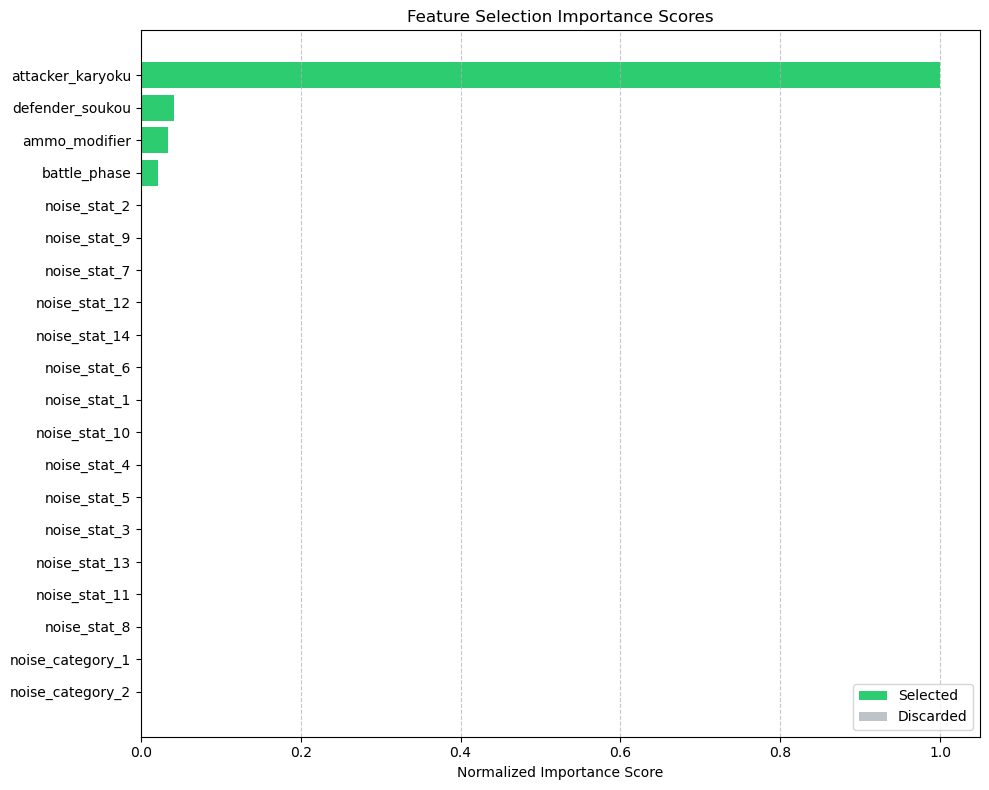

In [7]:
if __name__ == "__main__":
    run_feature_selection_demo()